In [1]:
from tqdm import tqdm
import polars as pl
import os
from joblib import Parallel, delayed

In [2]:
def load_item(owner, name):
    identifiers_path = f'/home/jortvd/thesis-data/in-repo-results-old/{owner}_{name}/identifiers.csv.gz'
    metadata_path = f'/mnt/stobox/in-repo-results-11-12-2025/{owner}_{name}/metadata.csv'

    identifiers = pl.read_csv(identifiers_path, has_header=False, new_columns=['i_before', 'i_after', 'lang_before', 'lang_after', 'num_moved', 'moved_len_mean', 'moved_len_std', 'num_common', 'common_len_mean', 'common_len_std', 'num_before', 'num_after'], truncate_ragged_lines=True)
    # metadata = pl.read_csv(metadata_path)

    return (identifiers, None)

def process_item(item, func):
    try:
        parts = item.split('_', 1)
        if len(parts) != 2: return None
        owner, name = parts

        identifiers, metadata = load_item(owner, name)

        return func(owner, name, identifiers, metadata)

    except Exception as e:
        # print(f"Error processing {item}: {e}")
        return None

def run_inrepo_func(func, n_jobs=-1):
    items = os.listdir('/home/jortvd/thesis-data/in-repo-results-old/')
    
    results = Parallel(n_jobs=n_jobs)(
        delayed(process_item)(item, func) for item in tqdm(items)
    )

    results = [i for i in results if i is not None]

    return results

In [3]:
def process_inrepo(owner, name, identifiers, _metadata):
    df_ids = identifiers.filter((pl.col('lang_before') != 'Rust') & (pl.col('lang_after') == 'Rust'))
    if df_ids.shape[0] == 0:
        return (f"{owner}/{name}", 0, 0, 0, 0)
    max_moved = df_ids['num_moved'].max()
    max_overlap = df_ids['num_common'].max()
    num_moved = df_ids.filter(pl.col('num_moved') == max_moved).shape[0]
    num_overlap = df_ids.filter(pl.col('num_common') == max_overlap).shape[0]

    return (f"{owner}/{name}", max_moved, max_overlap, num_moved, num_overlap)

results = run_inrepo_func(process_inrepo)
print(results)

  4%|▍         | 252/6467 [00:01<00:33, 186.14it/s]/home/jortvd/Documents/GitKraken/rust-migration-thesis/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
100%|██████████| 6467/6467 [00:35<00:00, 180.36it/s]


[('icedland/iced', 16, 19970, 10, 10), ('TabbyML/tabby', 55, 890, 1, 1), ('afadil/wealthfolio', 11, 639, 4, 36), ('mkeeter/fidget', 15, 105, 15, 12), ('near/create-near-app', 12, 21, 4, 2), ('opensourcecheemsburgers/ubiquity', 90, 117, 24, 6), ('wahn/rs_pbrt', 29, 30, 39, 3), ('spyglass-search/spyglass', 34, 307, 2, 1), ('longbridge/rust-i18n', 0, 0, 0, 0), ('zeqianli/tgv', 0, 3, 820, 385), ('freetonik/textpod', 0, 0, 0, 0), ('m1guelpf/tinyvector', 0, 0, 0, 0), ('getsentry/symbolic', 64, 409, 1, 9), ('osmosis-labs/osmosis', 7, 380, 78, 6), ('komora-io/concurrent-map', 0, 0, 0, 0), ('resyncgg/dacquiri', 0, 0, 0, 0), ('fuyoo/bs-redis-desktop-client', 23, 33, 40, 45), ('tangle-network/blueprint', 27, 70, 208, 11), ('dphilla/boxer', 87, 101, 60, 48), ('AtheMathmo/rusty-machine', 0, 0, 0, 0), ('pest-parser/pest', 0, 0, 1035, 1035), ('pcwalton/offset-allocator', 0, 0, 0, 0), ('quarylabs/sqruff', 6, 210, 33, 2), ('guibranco/BancosBrasileiros', 0, 21, 5481, 120), ('joamag/boytacean', 21, 179, 

In [4]:
for result in results:
    if result[0] == "cjdelisle/cjdns":
        print(result)

('cjdelisle/cjdns', 124, 730, 1, 1)


In [ ]:
df_rust = pl.read_csv("../../migration-status/results/repositories_with_rust_over_250_stars.csv", has_header=True, new_columns=['lang', 'repo', 'stars', 'rust', 'langs'])
df_rust = df_rust.filter(pl.col('stars') >= 300)
 
print(f"Total in-repo results: {len(results)} and total repos with Rust: {df_rust.shape[0]}")
inrepo_results = [r for r in results if r[0] in df_rust['repo'].to_list()]
print(len(inrepo_results))

Total in-repo results: 6249 and total repos with Rust: 6977
5590


In [12]:
df_verified = pl.read_csv("../data/verified_characteristics.csv", separator=';')
df_chars = pl.read_csv("../data/characteristics.csv", separator=';')

inrepo_labeled = []
for repo, max_moved, max_overlap, _, _ in inrepo_results:
    verified_row = df_verified.filter(pl.col('Project') == repo)
    char_row = df_chars.filter(pl.col('Project') == repo)
    is_verified = verified_row.shape[0] > 0 and verified_row.select(pl.col('Original project')).item() == None
    is_migrated = char_row.shape[0] > 0 and char_row.select(pl.col('Original project')).item() == 'Same'
    inrepo_labeled.append((repo, max_moved, max_overlap, is_verified, is_migrated))

In [13]:
print(f"Total in-repo labeled: {len(inrepo_labeled)}")
print(f"Total verified: {sum(1 for r in inrepo_labeled if r[3])}")
print(f"Total migrated: {sum(1 for r in inrepo_labeled if r[4])}")

Total in-repo labeled: 5590
Total verified: 23
Total migrated: 186


In [21]:
import polars as pl
import numpy as np
import itertools
from tqdm import tqdm
from sklearn.metrics import f1_score, precision_score, recall_score

df = pl.DataFrame(
    inrepo_labeled, 
    schema=["repo", "max_moved", "max_overlap", "is_verified", "is_migr"],
    orient="row"
)

y_true_verified = df["is_verified"].to_numpy()
y_true_migr = df["is_migr"].to_numpy()

v1 = df["max_moved"].to_numpy()
v2 = df["max_overlap"].to_numpy()

v1_steps = np.unique(v1)
v2_steps = np.unique(v2)

best_f1 = -1
best_metrics = {}
best_thresholds = (0, 0)

total_evals = len(v1_steps) * len(v2_steps)

def calc_f1(y_true, y_pred):
    tp = np.count_nonzero((y_true == 1) & (y_pred == 1))
    fp = np.count_nonzero(y_pred) - tp
    fn = np.count_nonzero(y_true) - tp
    denominator = (2 * tp) + fp + fn
    return (2 * tp) / denominator if denominator > 0 else 0

for t1, t2 in tqdm(itertools.product(v1_steps, v2_steps), total=total_evals, desc="Optimizing is_verified"):
    y_pred = (v1 >= t1) | (v2 >= t2)
    
    f1 = calc_f1(y_true_verified, y_pred)
    if f1 > best_f1:
        best_f1 = f1
        best_thresholds = (t1, t2)

opt_t1, opt_t2 = best_thresholds
final_pred = (v1 >= opt_t1) | (v2 >= opt_t2)

print("Optimal thresholds:")
print(f"  max_moved >= {opt_t1:.4f}")
print(f"  max_overlap >= {opt_t2:.4f}\n")

print("Results for is_verified (target)")
print(f"  F1 Score:  {f1_score(y_true_verified, final_pred, zero_division=0):.4f}")
print(f"  Precision: {precision_score(y_true_verified, final_pred, zero_division=0):.4f}")
print(f"  Recall:    {recall_score(y_true_verified, final_pred, zero_division=0):.4f}\n")

print("Results for is_migrated")
print(f"  F1 Score:  {f1_score(y_true_migr, final_pred, zero_division=0):.4f}")
print(f"  Precision: {precision_score(y_true_migr, final_pred, zero_division=0):.4f}")
print(f"  Recall:    {recall_score(y_true_migr, final_pred, zero_division=0):.4f}")

Optimizing is_verified: 100%|██████████| 328496/328496 [00:06<00:00, 53755.91it/s]

Optimal thresholds:
  max_moved >= 298.0000
  max_overlap >= 21945.0000

Results for is_verified (target)
  F1 Score:  0.0842
  Precision: 0.0479
  Recall:    0.3478

Results for is_migrated
  F1 Score:  0.3229
  Precision: 0.3413
  Recall:    0.3065


In [30]:
crossrepo_results = pl.read_csv("../../migration-status/results/final_symbols_compare_2.csv", has_header=True, new_columns=['from', 'index', 'to', 'lang', 'sim'])

In [31]:
print(f"Total cross-repo results: {crossrepo_results.shape[0]}")
crossrepo_results = [r for r in crossrepo_results.to_numpy() if r[0] in df_rust['repo'].to_list() and r[1] == 0]
print(len(crossrepo_results))

Total cross-repo results: 31784
5677


In [34]:
df_verified = pl.read_csv("../data/verified_characteristics.csv", separator=';')
df_chars = pl.read_csv("../data/characteristics.csv", separator=';')

crossrepo_labeled = []
for repo, _, _, _, sim in crossrepo_results:
    verified_row = df_verified.filter(pl.col('Project') == repo)
    char_row = df_chars.filter(pl.col('Project') == repo)
    is_verified = verified_row.shape[0] > 0 and verified_row.select(pl.col('Original project')).item() != None
    is_migrated = char_row.shape[0] > 0 and char_row.select(pl.col('Original project')).item() != 'Same'
    crossrepo_labeled.append((repo, sim, is_verified, is_migrated))

In [35]:
print(f"Total cross-repo labeled: {len(crossrepo_labeled)}")
print(f"Total verified: {sum(1 for r in crossrepo_labeled if r[2])}")
print(f"Total migrated: {sum(1 for r in crossrepo_labeled if r[3])}")

Total cross-repo labeled: 5677
Total verified: 12
Total migrated: 93


In [40]:
import polars as pl
import numpy as np
import itertools
from tqdm import tqdm
from sklearn.metrics import f1_score, precision_score, recall_score

df = pl.DataFrame(
    crossrepo_labeled, 
    schema=["repo", "sim", "is_verified", "is_migr"],
    orient="row"
)

y_true_verified = df["is_verified"].to_numpy()
y_true_migr = df["is_migr"].to_numpy()

v1 = df["sim"].to_numpy()

v1_steps = np.unique(v1)

best_f1 = -1
best_metrics = {}
best_thresholds = 0

def calc_f1(y_true, y_pred):
    tp = np.count_nonzero((y_true == 1) & (y_pred == 1))
    fp = np.count_nonzero(y_pred) - tp
    fn = np.count_nonzero(y_true) - tp
    denominator = (2 * tp) + fp + fn
    return (2 * tp) / denominator if denominator > 0 else 0

for t1 in tqdm(v1_steps, total=len(v1_steps), desc="Optimizing is_verified"):
    y_pred = (v1 >= t1)
    
    f1 = calc_f1(y_true_verified, y_pred)
    if f1 > best_f1:
        best_f1 = f1
        best_thresholds = t1

opt_t1 = best_thresholds
final_pred = (v1 >= opt_t1)

print("Optimal thresholds:")
print(f"  sim >= {opt_t1:.4f}")

print("Results for is_verified")
print(f"  F1 Score:  {f1_score(y_true_verified, final_pred, zero_division=0):.4f}")
print(f"  Precision: {precision_score(y_true_verified, final_pred, zero_division=0):.4f}")
print(f"  Recall:    {recall_score(y_true_verified, final_pred, zero_division=0):.4f}\n")

print("Results for is_migrated")
print(f"  F1 Score:  {f1_score(y_true_migr, final_pred, zero_division=0):.4f}")
print(f"  Precision: {precision_score(y_true_migr, final_pred, zero_division=0):.4f}")
print(f"  Recall:    {recall_score(y_true_migr, final_pred, zero_division=0):.4f}")

Optimizing is_verified: 100%|██████████| 313/313 [00:00<00:00, 63818.83it/s]

Optimal thresholds:
  sim >= 0.1436
Results for is_verified
  F1 Score:  0.0365
  Precision: 0.0188
  Recall:    0.5833

Results for is_migrated
  F1 Score:  0.1204
  Precision: 0.0753
  Recall:    0.3011


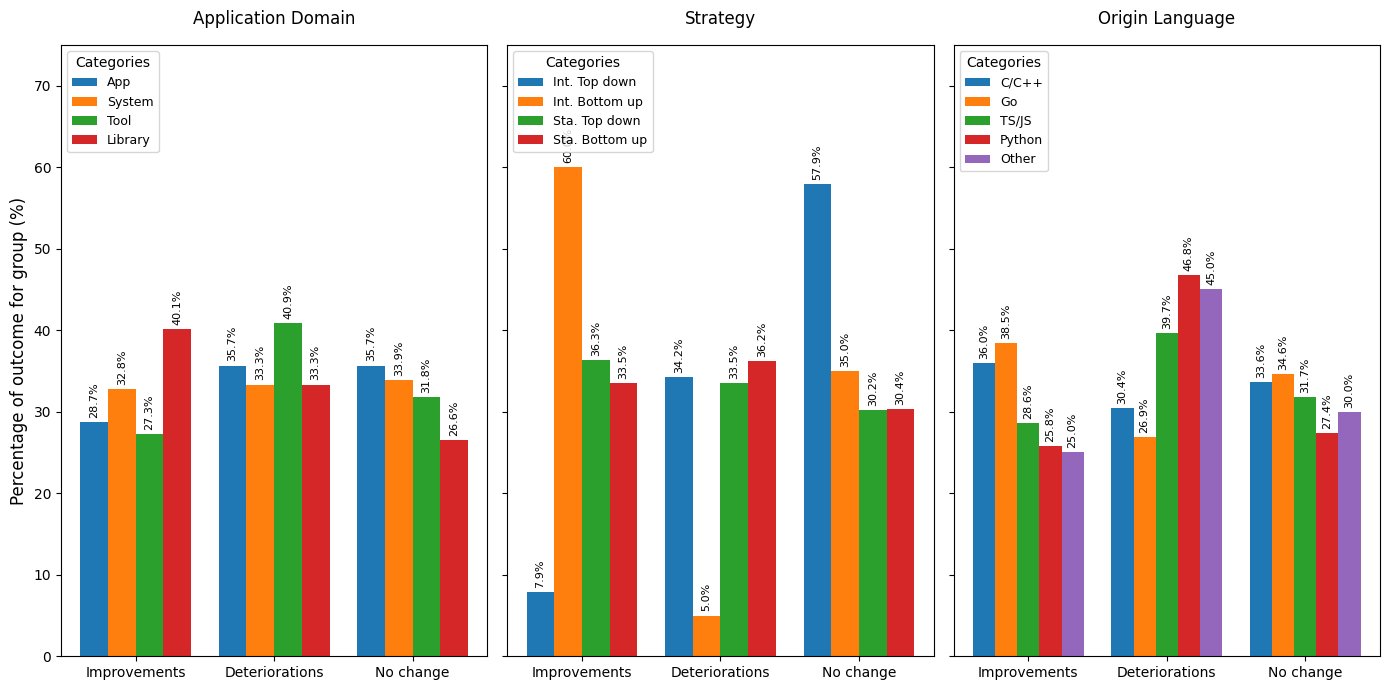

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Metrics are our main X-axis groups
metrics = ['Improvements', 'Deteriorations', 'No change']

# --- Raw Data ---
domain_labels = ['App', 'System', 'Tool', 'Library']
domain_data = [
    [74, 92, 92],  # App
    [57, 58, 59],  # System
    [6, 9, 7],     # Tool
    [71, 59, 47]   # Library
]

strategy_labels = ['Int. Top down', 'Int. Bottom up', 'Sta. Top down', 'Sta. Bottom up']
strategy_data = [
    [3, 13, 22],     # Int. Top down
    [12, 1, 7],      # Int. Bottom up
    [118, 109, 98],  # Sta. Top down
    [75, 81, 68]     # Sta. Bottom up
]

language_labels = ['C/C++', 'Go', 'TS/JS', 'Python', 'Other']
language_data = [
    [91, 77, 85],  # C/C++
    [50, 35, 45],  # Go
    [36, 50, 40],  # TS/JS
    [16, 29, 17],  # Python
    [15, 27, 18]   # Other
]

# --- Helper Function for Percentages ---
def convert_to_percentages(data_matrix):
    """Converts raw counts to percentages row by row."""
    pct_matrix = []
    for row in data_matrix:
        total = sum(row)
        # Avoid division by zero in case of empty rows
        pct_row = [(val / total * 100) if total > 0 else 0 for val in row]
        pct_matrix.append(pct_row)
    return pct_matrix

def plot_on_ax(ax, metric_labels, item_labels, data_matrix, title):
    """Plots the grouped bar chart on a specific subplot axis."""
    x = np.arange(len(metric_labels))
    num_items = len(item_labels)
    
    total_group_width = 0.8
    width = total_group_width / num_items
    start_x = x - (total_group_width / 2) + (width / 2)
    
    for i, (item_label, item_data) in enumerate(zip(item_labels, data_matrix)):
        bar_positions = start_x + (i * width)
        rects = ax.bar(bar_positions, item_data, width, label=item_label)
        
        # Attach percentage labels above the bars
        ax.bar_label(rects, fmt='%.1f%%', padding=3, fontsize=8, rotation=90)
        
    ax.set_title(title, pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(metric_labels)
    
    # Place legend inside each subplot, slightly adjusted to prevent heavy overlap
    ax.legend(title="Categories", fontsize=9, loc='upper left', bbox_to_anchor=(0, 1.0))
    
    # Add some headroom for the labels and legends
    ax.margins(y=0.25)

if __name__ == "__main__":
    # 1. Convert all data to percentages
    domain_pct = convert_to_percentages(domain_data)
    strategy_pct = convert_to_percentages(strategy_data)
    language_pct = convert_to_percentages(language_data)

    # 2. Set up a single figure with 3 horizontal subplots and a shared Y-axis
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(14, 7), sharey=True)
    # fig.suptitle('Post-Migration Outcomes (Percentages)', fontsize=16, fontweight='bold', y=1.05)

    # 3. Plot each group onto its respective axis
    plot_on_ax(axes[0], metrics, domain_labels, domain_pct, 'Application Domain')
    plot_on_ax(axes[1], metrics, strategy_labels, strategy_pct, 'Strategy')
    plot_on_ax(axes[2], metrics, language_labels, language_pct, 'Origin Language')

    # 4. Set the shared Y-axis label only on the leftmost graph
    axes[0].set_ylabel('Percentage of outcome for group (%)', fontsize=12)

    # Adjust layout to prevent clipping of labels
    plt.tight_layout()
    plt.show()